# 🚗 Car Price Prediction using Machine Learning

This project is part of my Data Science Internship.

The objective of this project is to build a machine learning model to predict car prices based on various features such as fuel type, transmission, and car age.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

## 📥 Uploading the Dataset

In this step, we upload the car dataset into Google Colab for further analysis.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data (1).csv


## 📊 Loading the Dataset

Here, we load the dataset into a pandas DataFrame and view the first few rows.

In [3]:
df = pd.read_csv("car data.csv")   # change if filename is different
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## ⚙️ Data Cleaning

We check for missing values and convert categorical data into numerical format for machine learning.

In [4]:
print(df.isnull().sum())

df = df.dropna()

df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol':0, 'Diesel':1, 'CNG':2})
df['Selling_type'] = df['Selling_type'].map({'Dealer':0, 'Individual':1})
df['Transmission'] = df['Transmission'].map({'Manual':0, 'Automatic':1})

df.head()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


## 🛠️ Feature Engineering

We create a new feature called 'Car Age' from the year column and remove unnecessary columns.

In [5]:
df['Car_Age'] = 2024 - df['Year']
df = df.drop(['Car_Name', 'Year'], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,0,0,0,0,10
1,4.75,9.54,43000,1,0,0,0,11
2,7.25,9.85,6900,0,0,0,0,7
3,2.85,4.15,5200,0,0,0,0,13
4,4.60,6.87,42450,1,0,0,0,10


## 📌 Defining Features and Target

We separate the dataset into input features (X) and target variable (y).

In [6]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

## 🔀 Splitting the Dataset

We split the dataset into training and testing sets to evaluate model performance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 🤖 Model Training

We use the Random Forest Regressor to train the model on the dataset.

In [8]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

## 🔮 Making Predictions

The trained model is used to predict car prices on the test data.

In [9]:
y_pred = model.predict(X_test)

## 📈 Model Evaluation

We evaluate the model using R2 score and Mean Absolute Error.

In [10]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)

R2 Score: 0.956249489555612
Mean Absolute Error: 0.6560377049180333


## 📊 Visualization

This graph compares actual prices with predicted prices.

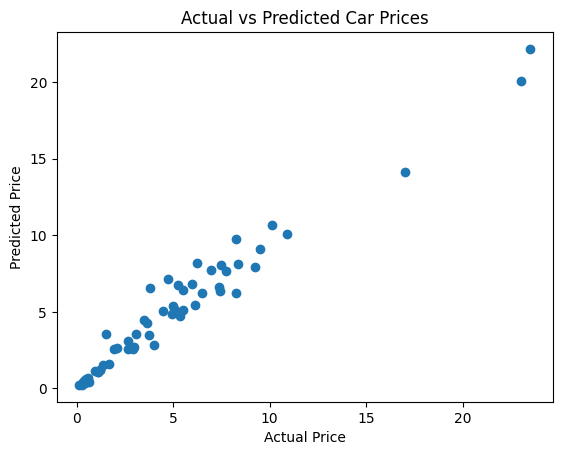

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

## ✅ Conclusion

In this project, we successfully built a machine learning model to predict car prices.

Key Learnings:
- Data preprocessing and cleaning
- Feature engineering
- Regression modeling
- Model evaluation techniques

The model performed well and demonstrated the practical use of machine learning in real-world scenarios.